In [47]:
%pip install pandas numpy matplotlib pgmpy networkx

%pip install "numpy<2"

  Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl (5.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 7.34.1 which is incompatible

# Projeto: Previsão de Resultados de Futebol - Liga Portuguesa
## Parte 1: Redes Bayesianas

### 1. Configuração do Ambiente e Carregamento de Dados

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, HillClimbSearch
from pgmpy.inference import VariableElimination
import networkx as nx

df = pd.read_csv('dataset.csv')

# Selecionar colunas relevantes para a Rede Bayesiana
cols = ['ht_form', 'at_form', 'ht_attack', 'at_attack', 'h2h_dominance', 'odds_favorite', 'result']
data = df[cols].copy()

data.head()

,ht_form,at_form,ht_attack,at_attack,h2h_dominance,odds_favorite,result
0,good,below avg,average,average,balanced,home,A
1,average,average,average,weak,balanced,home,D
2,average,average,average,average,balanced,home,D
3,poor,poor,weak,weak,balanced,home,H
4,poor,good,weak,above avg,balanced,balanced,H


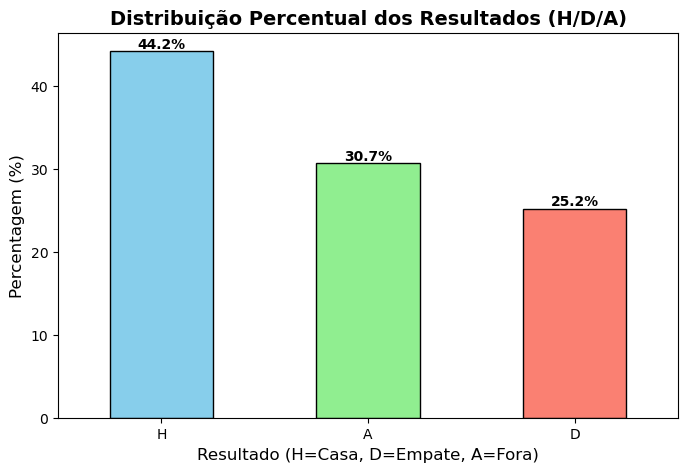

In [49]:
percentagens = data['result'].value_counts(normalize=True) * 100

# 2. Criar a figura
plt.figure(figsize=(8, 5))
ax = percentagens.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'], edgecolor='black')

plt.title('Distribuição Percentual dos Resultados (H/D/A)', fontsize=14, fontweight='bold')
plt.xlabel('Resultado (H=Casa, D=Empate, A=Fora)', fontsize=12)
plt.ylabel('Percentagem (%)', fontsize=12)
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.show()

### 2. Construção da Estrutura da Rede Bayesiana

Nesta secção, avaliamos duas estratégias:
1. **Knowledge Engineering**: Estrutura manual baseada no conhecimento do domínio.
2. **Aprendizagem Automática**: Estrutura aprendida a partir dos dados.

#### 2.1. Estrutura Manual (Knowledge Engineering)
Definimos uma estrutura onde a forma e o ataque de ambas as equipas, juntamente com o histórico (H2H) e as odds, influenciam o resultado final.

In [50]:
ligacoes = [
    # O ataque e os golos marcados geram pontos (forma)
    ('ht_attack', 'ht_form'),
    ('at_attack', 'at_form'),
    
    # A forma (pontos ganhos) e o histórico afetam as odds (as casas de apostas olham muito para os pontos)
    ('ht_form', 'odds_favorite'),
    ('at_form', 'odds_favorite'),
    ('h2h_dominance', 'odds_favorite'),
    
    # A capacidade de ataque e o histórico influenciam o resultado do jogo de hoje
    ('ht_attack', 'result'),
    ('at_attack', 'result'),
    ('h2h_dominance', 'result'),
    
    # As odds captam informação latente (ex: lesões, castigos) que também afeta o resultado
    ('odds_favorite', 'result')
]

manual_model = DiscreteBayesianNetwork(ligacoes)

print("Nós:", manual_model.nodes())
print("Arestas:", manual_model.edges())

Nós: ['ht_attack', 'ht_form', 'at_attack', 'at_form', 'odds_favorite', 'h2h_dominance', 'result']
Arestas: [('ht_attack', 'ht_form'), ('ht_attack', 'result'), ('ht_form', 'odds_favorite'), ('at_attack', 'at_form'), ('at_attack', 'result'), ('at_form', 'odds_favorite'), ('odds_favorite', 'result'), ('h2h_dominance', 'odds_favorite'), ('h2h_dominance', 'result')]


#### 2.2. Aprendizagem Automática de Estrutura
Utilizamos o algoritmo Hill Climb Search com a métrica BIC (Bayesian Information Criterion) para encontrar a melhor estrutura de rede baseada nos dados.

In [51]:
hc = HillClimbSearch(data)
best_model_structure = hc.estimate(scoring_method="bic-d")
auto_model = DiscreteBayesianNetwork(best_model_structure.edges())

print("Arestas aprendidas:", auto_model.edges())

/var/folders/j1/vm53k26x2qbc0hxh9tp8sd3h0000gn/T/ipykernel_40773/2620387882.py:1: FutureWarning: HillClimbSearch is deprecated. Please use pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(data)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Arestas aprendidas: [('ht_form', 'h2h_dominance'), ('ht_form', 'odds_favorite'), ('h2h_dominance', 'odds_favorite'), ('h2h_dominance', 'result'), ('h2h_dominance', 'at_attack'), ('odds_favorite', 'at_attack'), ('odds_favorite', 'result'), ('odds_favorite', 'at_form'), ('ht_attack', 'ht_form'), ('at_attack', 'at_form')]


### 3. Análise da Rede Bayesiana utilizando D-separação

A D-separação permite identificar independências condicionais na rede.

In [52]:
print("Independências Locais (Manual Model - result):")
print(manual_model.local_independencies('result'))

print("\nIndependências Globais (Auto Model - subset):")
all_independencies = auto_model.get_independencies()
print(list(all_independencies.independencies)[:]) 

Independências Locais (Manual Model - result):
(result ⟂ at_form, ht_form | at_attack, h2h_dominance, ht_attack, odds_favorite)

Independências Globais (Auto Model - subset):
[(at_attack ⟂ result | h2h_dominance, odds_favorite), (at_form ⟂ ht_attack | at_attack, odds_favorite), (at_attack ⟂ ht_form | h2h_dominance, odds_favorite), (ht_attack ⟂ result | h2h_dominance, odds_favorite), (ht_form ⟂ result | h2h_dominance, odds_favorite), (h2h_dominance ⟂ ht_attack | ht_form), (at_form ⟂ result | at_attack, odds_favorite), (ht_attack ⟂ odds_favorite | ht_form), (at_form ⟂ ht_form | at_attack, odds_favorite), (at_form ⟂ h2h_dominance | at_attack, odds_favorite), (at_attack ⟂ ht_attack | h2h_dominance, odds_favorite)]


In [53]:
def testar_d_separacao(modelo, origem, destino, observados=[]):
    """
    Verifica se a informação flui da origem para o destino.
    Retorna True se estiverem DEPENDENTES (Caminho Ativo).
    Retorna False se estiverem INDEPENDENTES (D-Separados).
    """
    # Descobre todos os nós alcançáveis a partir da 'origem'
    alcançaveis = modelo.active_trail_nodes(origem, observed=observados)[origem]
    
    # Verifica se o 'destino' está na lista de alcançáveis
    caminho_ativo = destino in alcançaveis
    
    obs_str = f" (Observando: {observados})" if observados else " (Nenhuma observação)"
    status = "ATIVO (Dependentes)" if caminho_ativo else "BLOQUEADO (D-Separados)"
    
    print(f"Caminho {origem} <-> {destino}{obs_str}: {status}")
    return caminho_ativo

In [54]:
print("--- TESTES DE D-SEPARAÇÃO (PARTE 1 - QUESTÃO 2) ---\n")

# ---------------------------------------------------------
# EXEMPLO 1: ESTRUTURA EM V (Colisor)
# Caminho: ht_attack -> result <- at_attack
# Regra: Inativo por defeito. Fica ativo se o colisor ('result') for observado.
# ---------------------------------------------------------
print("EXEMPLO 1: Estrutura em V (Explaining Away)")
testar_d_separacao(manual_model, 'ht_attack', 'at_attack', observados=[])
testar_d_separacao(manual_model, 'ht_attack', 'at_attack', observados=['result'])


# ---------------------------------------------------------
# EXEMPLO 2: CASCATA (Chain)
# Caminho: ht_attack -> ht_form -> odds_favorite
# Regra: Ativo por defeito. Fica bloqueado se o nó intermédio ('ht_form') for observado.
# ---------------------------------------------------------
print("\nEXEMPLO 2: Cascata")
testar_d_separacao(manual_model, 'ht_attack', 'odds_favorite', observados=[])
testar_d_separacao(manual_model, 'ht_attack', 'odds_favorite', observados=['ht_form'])


--- TESTES DE D-SEPARAÇÃO (PARTE 1 - QUESTÃO 2) ---

EXEMPLO 1: Estrutura em V (Explaining Away)
Caminho ht_attack <-> at_attack (Nenhuma observação): BLOQUEADO (D-Separados)
Caminho ht_attack <-> at_attack (Observando: ['result']): ATIVO (Dependentes)

EXEMPLO 2: Cascata
Caminho ht_attack <-> odds_favorite (Nenhuma observação): ATIVO (Dependentes)
Caminho ht_attack <-> odds_favorite (Observando: ['ht_form']): BLOQUEADO (D-Separados)


False

### 4. Aprendizagem de Parâmetros

Comparamos duas abordagens para estimar as CPTs:
1. **Maximum Likelihood Estimation (MLE)**
2. **Bayesian Estimation**

In [55]:
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator

print("="*50)
print("1. ABORDAGEM MAXIMUM LIKELIHOOD ESTIMATION (MLE)")
print("="*50)

# Usar a rede 'manual_model' e treinar APENAS com os dados de treino
manual_model.fit(data, estimator=MaximumLikelihoodEstimator)

CPDs_mle = manual_model.get_cpds()
for cpd in CPDs_mle:
    print(f"--- Variável: {cpd.variable} ---")
    try:
        print(cpd.to_dataframe()) 
    except ValueError:
        print(cpd)
    print('\n')

1. ABORDAGEM MAXIMUM LIKELIHOOD ESTIMATION (MLE)
--- Variável: ht_attack ---
+----------------------+----------+
| ht_attack(above avg) | 0.185026 |
+----------------------+----------+
| ht_attack(average)   | 0.501343 |
+----------------------+----------+
| ht_attack(strong)    | 0.110335 |
+----------------------+----------+
| ht_attack(weak)      | 0.203296 |
+----------------------+----------+


--- Variável: ht_form ---
ht_form     average  below avg  excellent      good      poor
ht_attack                                                    
above avg  0.396902   0.152953   0.131655  0.303001  0.015489
average    0.339764   0.426224   0.008932  0.080743  0.144337
strong     0.102273   0.009740   0.500000  0.386364  0.001623
weak       0.067841   0.425551   0.000000  0.001762  0.504846


--- Variável: at_attack ---
+----------------------+----------+
| at_attack(above avg) | 0.192549 |
+----------------------+----------+
| at_attack(average)   | 0.505105 |
+----------------------+-

In [56]:
print("2. ABORDAGEM ESTIMAÇÃO BAYESIANA (BDeu)")
manual_model.fit(data, estimator=BayesianEstimator, prior_type="BDeu", equivalent_sample_size=10)

CPDs_bayes = manual_model.get_cpds()
for cpd in CPDs_bayes:
    print(f"--- Variável: {cpd.variable} ---")
    try:
        print(cpd.to_dataframe())
    except ValueError:
        print(cpd)
    print('\n')

2. ABORDAGEM ESTIMAÇÃO BAYESIANA (BDeu)
--- Variável: ht_attack ---
+----------------------+----------+
| ht_attack(above avg) | 0.185142 |
+----------------------+----------+
| ht_attack(average)   | 0.500894 |
+----------------------+----------+
| ht_attack(strong)    | 0.110585 |
+----------------------+----------+
| ht_attack(weak)      | 0.203379 |
+----------------------+----------+


--- Variável: ht_form ---
ht_form     average  below avg  excellent      good      poor
ht_attack                                                    
above avg  0.396427   0.153066   0.131820  0.302752  0.015934
average    0.339639   0.426022   0.009102  0.080850  0.144387
strong     0.102668   0.010509   0.498787  0.385610  0.002425
weak       0.068132   0.425055   0.000440  0.002198  0.504176


--- Variável: at_attack ---
+----------------------+----------+
| at_attack(above avg) | 0.192652 |
+----------------------+----------+
| at_attack(average)   | 0.504649 |
+----------------------+----------

### 5. Inferência Probabilística

Demonstração da utilização da rede para prever resultados com base em diferentes cenários.

In [57]:
print("=== CATEGORIAS DE CADA ATRIBUTO ===\n")

for coluna in data.columns:
    opcoes = data[coluna].unique().tolist()
    
    print(f"Variável: {coluna}")
    print(f"Opções disponíveis: {opcoes}")
    print("-" * 40)

=== CATEGORIAS DE CADA ATRIBUTO ===

Variável: ht_form
Opções disponíveis: ['good', 'average', 'poor', 'excellent', 'below avg']
----------------------------------------
Variável: at_form
Opções disponíveis: ['below avg', 'average', 'poor', 'good', 'excellent']
----------------------------------------
Variável: ht_attack
Opções disponíveis: ['average', 'weak', 'above avg', 'strong']
----------------------------------------
Variável: at_attack
Opções disponíveis: ['average', 'weak', 'above avg', 'strong']
----------------------------------------
Variável: h2h_dominance
Opções disponíveis: ['balanced', 'away_dominant', 'home_dominant']
----------------------------------------
Variável: odds_favorite
Opções disponíveis: ['home', 'balanced', 'away']
----------------------------------------
Variável: result
Opções disponíveis: ['A', 'D', 'H']
----------------------------------------


In [58]:
from pgmpy.inference import VariableElimination

# Inicializar o motor de inferência com a tua rede treinada
infer = VariableElimination(manual_model)

print("="*60)
print("INFERÊNCIAS PROBABILÍSTICAS (PARTE 1 - PASSO 4)")
print("="*60)

# ---------------------------------------------------------
# 1. PREVISÃO CLÁSSICA (Causa -> Efeito)
# "O Cenário Perfeito para a Casa"
# ---------------------------------------------------------
print("\n1. Qual a probabilidade de vitória (H/D/A) se a equipa da casa tiver")
print("forma 'excellent', ataque 'strong' e domínio no histórico ('home_dominant')?")
q1 = infer.query(variables=['result'], 
                 evidence={'ht_form': 'excellent', 'ht_attack': 'strong', 'h2h_dominance': 'home_dominant'})
print(q1)

# ---------------------------------------------------------
# 2. INFERÊNCIA DIAGNÓSTICA (Efeito -> Causa)
# "A Anatomia de uma Surpresa"
# ---------------------------------------------------------
print("\n2. A equipa da casa estava em forma 'poor', mas GANHOU ('H').")
print("Qual era a probabilidade de a equipa de fora também estar em má forma ('poor' ou 'below avg')?")
q2 = infer.query(variables=['at_form'], 
                 evidence={'result': 'H', 'ht_form': 'poor'})
print(q2)

# ---------------------------------------------------------
# 3. PREVER O COMPORTAMENTO DAS CASAS DE APOSTAS
# ---------------------------------------------------------
print("\n3. Se o jogo for muito equilibrado ('balanced' no histórico, ataques 'average'),")
print("para onde pendem as casas de apostas (odds_favorite)?")
q3 = infer.query(variables=['odds_favorite'], 
                 evidence={'h2h_dominance': 'balanced', 'ht_attack': 'average', 'at_attack': 'average'})
print(q3)

# ---------------------------------------------------------
# 4. EXPLAINING AWAY (Na Prática!)
# "O Efeito de um Empate"
# ---------------------------------------------------------
print("\n4. A equipa da casa tem um ataque 'strong'.")
print("Sem saber o resultado, como prevemos o ataque de fora?")
q4a = infer.query(variables=['at_attack'], evidence={'ht_attack': 'strong'})
print(q4a)

print("Mas e se soubermos que o jogo acabou empatado ('D')?")
print("Como isso altera a nossa perceção do ataque da equipa de fora?")
q4b = infer.query(variables=['at_attack'], evidence={'ht_attack': 'strong', 'result': 'D'})
print(q4b)

# ---------------------------------------------------------
# 5. O PESO DO HISTÓRICO (H2H)
# ---------------------------------------------------------
print("\n5. As odds dão favoritismo à equipa de FORA ('away').")
print("Sabendo isto, qual a probabilidade de o histórico ser dominado pela equipa da CASA ('home_dominant')?")
print("(Ou seja, as casas de apostas estão a ignorar o histórico?)")
q5 = infer.query(variables=['h2h_dominance'], 
                 evidence={'odds_favorite': 'away'})
print(q5)

INFERÊNCIAS PROBABILÍSTICAS (PARTE 1 - PASSO 4)

1. Qual a probabilidade de vitória (H/D/A) se a equipa da casa tiver
forma 'excellent', ataque 'strong' e domínio no histórico ('home_dominant')?
+-----------+---------------+
| result    |   phi(result) |
+===========+===============+
| result(A) |        0.0720 |
+-----------+---------------+
| result(D) |        0.1430 |
+-----------+---------------+
| result(H) |        0.7850 |
+-----------+---------------+

2. A equipa da casa estava em forma 'poor', mas GANHOU ('H').
Qual era a probabilidade de a equipa de fora também estar em má forma ('poor' ou 'below avg')?
+--------------------+----------------+
| at_form            |   phi(at_form) |
+====================+================+
| at_form(average)   |         0.2711 |
+--------------------+----------------+
| at_form(below avg) |         0.3492 |
+--------------------+----------------+
| at_form(excellent) |         0.0609 |
+--------------------+----------------+
| at_form(good)  

# Parte 2: Classificação Probabilística e Quantificação de Incerteza

### 1. Treino e Avaliação do Classificador Naive Bayes

Preparamos os dados (codificação de variáveis categóricas) e treinamos um modelo Naive Bayes para prever o resultado (H/D/A).

In [59]:
import pandas as pd
import numpy as np

# 1. Primeiro, removemos as variáveis proibidas (Data Leakage e Identificadores)
colunas_proibidas = ['date', 'ht', 'at', 'hg', 'ag']
df_limpo = df.drop(columns=colunas_proibidas, errors='ignore')

# Separar logo o alvo (target) para ele não se misturar na seleção
y = df_limpo['result']
X_completo = df_limpo.drop(columns=['result'])

# Selecionar variáveis CONTÍNUAS (Tudo o que for número: int64, float64)
X_cont = X_completo.select_dtypes(include=[np.number])

# Selecionar variáveis DISCRETAS (Tudo o que NÃO for número: strings/objects)
X_disc = X_completo.select_dtypes(exclude=[np.number])

# =====================================================================

print(f"Encontradas {X_cont.shape[1]} Variáveis Contínuas:")
print(X_cont.columns.tolist())

print(f"\nEncontradas {X_disc.shape[1]} Variáveis Discretas:")
print(X_disc.columns.tolist())

Encontradas 18 Variáveis Contínuas:
['h_odds', 'd_odds', 'a_odds', 'ht_form_points', 'ht_form_goals_scored', 'ht_form_goals_conceded', 'ht_form_wins', 'at_form_points', 'at_form_goals_scored', 'at_form_goals_conceded', 'at_form_wins', 'ht_home_form_points', 'ht_home_form_goals_scored', 'at_away_form_points', 'at_away_form_goals_scored', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins']

Encontradas 7 Variáveis Discretas:
['ht_form', 'at_form', 'ht_attack', 'at_attack', 'joint_attack', 'h2h_dominance', 'odds_favorite']


In [60]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.preprocessing import StandardScaler


print("="*50)
print("GAUSSIAN NAIVE BAYES")
print("="*50)

# Divisão dos dados
X_temp, X_test, y_temp, y_test = train_test_split(X_cont, y, test_size=0.2, random_state=42)
X_train, X_cal, y_train, y_cal = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# 2. Inicializar o transformador (StandardScaler para padronização z-score)
scaler = StandardScaler() #

# 3. Aplicar o fit_transform APENAS no conjunto de treino
# O fit aprende a média e o desvio padrão apenas dos dados de treino
X_train_scaled = scaler.fit_transform(X_train) #[cite: 2]

# 4. Aplicar apenas o transform nos conjuntos de validação/teste 
# Isso garante que usamos a mesma escala (do treino) nos novos dados
X_cal_scaled = scaler.transform(X_cal) #[cite: 2]
X_test_scaled = scaler.transform(X_test) #[cite: 2]

# 5. Treinar o modelo com os dados transformados
nb_gauss = GaussianNB()
nb_gauss.fit(X_train_scaled, y_train)

# Fazer as previsões usando o conjunto de teste transformado
y_pred = nb_gauss.predict(X_test_scaled)
y_prob = nb_gauss.predict_proba(X_test_scaled)

# Avaliação
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Log Loss: {log_loss(y_test, y_prob):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

GAUSSIAN NAIVE BAYES
Accuracy: 0.4655
Log Loss: 2.1232

Classification Report:
              precision    recall  f1-score   support

           A       0.52      0.42      0.47       351
           D       0.28      0.51      0.36       274
           H       0.68      0.47      0.56       492

    accuracy                           0.47      1117
   macro avg       0.50      0.47      0.46      1117
weighted avg       0.53      0.47      0.48      1117



### 2. Conformal Prediction (Classificação)

Definimos prediction sets com garantia de cobertura (ex: 90%) utilizando o set de calibração.

In [61]:
class_mapping = {c: i for i, c in enumerate(nb_gauss.classes_)}

# Ajuste: garantir que y_cal e y_test são arrays/listas para iterar corretamente
y_cal_array = y_cal.values if hasattr(y_cal, 'values') else np.array(y_cal)
y_test_array = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

y_cal_idx = np.array([class_mapping[label] for label in y_cal_array])
y_test_idx = np.array([class_mapping[label] for label in y_test_array])

# --- PASSO A: FASE DE CALIBRAÇÃO ---
# Obter probabilidades no conjunto de calibração
cal_probs = nb_gauss.predict_proba(X_cal_scaled)

# Extrair a probabilidade que o modelo deu para a classe CORRETA de cada exemplo
true_class_probs = cal_probs[np.arange(len(y_cal_array)), y_cal_idx]

# Calcular os Scores de Não-Conformidade (1 - probabilidade da classe certa)
# Se o modelo tem muita certeza e acerta, o score é próximo de 0.
scores = 1.0 - true_class_probs

# Definir o nível de confiança (ex: 90% -> alpha = 0.10)
alpha = 0.10
n_cal = len(y_cal_array)

# Calcular o quantil corrigido matematicamente
q_level = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
q_level = min(q_level, 1.0) # Garantir que não ultrapassa 1.0
threshold = np.quantile(scores, q_level)

print(f"Nível de Confiança Alvo: {(1 - alpha)*100:.0f}%")
print(f"Limiar de Não-Conformidade Calculado: {threshold:.4f}\n")


# --- PASSO B: FASE DE PREDIÇÃO ---
# Criar os conjuntos de predição (Prediction Sets) para os dados de teste
test_probs = nb_gauss.predict_proba(X_test_scaled)

# Uma classe entra no conjunto se a sua "não-conformidade" for menor ou igual ao limiar
prediction_sets = (1.0 - test_probs) <= threshold

# --- PASSO C: AVALIAÇÃO ---
# Cobertura Empírica (empirical coverage): A classe real está dentro do conjunto previsto?
is_covered = prediction_sets[np.arange(len(y_test_array)), y_test_idx]
empirical_coverage = np.mean(is_covered)

# Tamanho Médio do Conjunto (mean interval width equivalente): Quantas opções o modelo está a dar em média?
set_sizes = prediction_sets.sum(axis=1)
mean_set_size = np.mean(set_sizes)

print(f"Cobertura Real Obtida: {empirical_coverage*100:.2f}% (Deve estar próximo do Alvo de {(1-alpha)*100:.0f}%)")
print(f"Tamanho Médio do Conjunto de Predição: {mean_set_size:.2f} classes\n")

# Mostrar alguns exemplos práticos
print("Exemplos de Conjuntos de Predição:")
for i in range(5):
    # Encontrar quais as classes que ficaram marcadas como "True" no set
    predicted_classes = nb_gauss.classes_[prediction_sets[i]]
    true_class = y_test_array[i]
    
    print(f"Exemplo {i+1}:")
    print(f"  Classe Real: {true_class}")
    print(f"  Conjunto Previsto (CP): {predicted_classes}")
    print(f"  Atingiu a Cobertura? {'Sim' if true_class in predicted_classes else 'Não'}\n")

Nível de Confiança Alvo: 90%
Limiar de Não-Conformidade Calculado: 0.9845

Cobertura Real Obtida: 89.17% (Deve estar próximo do Alvo de 90%)
Tamanho Médio do Conjunto de Predição: 2.26 classes

Exemplos de Conjuntos de Predição:
Exemplo 1:
  Classe Real: H
  Conjunto Previsto (CP): ['A' 'D']
  Atingiu a Cobertura? Não

Exemplo 2:
  Classe Real: H
  Conjunto Previsto (CP): ['H']
  Atingiu a Cobertura? Sim

Exemplo 3:
  Classe Real: A
  Conjunto Previsto (CP): ['A' 'D' 'H']
  Atingiu a Cobertura? Sim

Exemplo 4:
  Classe Real: H
  Conjunto Previsto (CP): ['A' 'D' 'H']
  Atingiu a Cobertura? Sim

Exemplo 5:
  Classe Real: A
  Conjunto Previsto (CP): ['A' 'D' 'H']
  Atingiu a Cobertura? Sim



### 3. Calibração do Modelo

Análise de Reliability Diagram para a classe Vitória em Casa (H).

AVALIAÇÃO DE CALIBRAÇÃO (Classe 'H')
Log Loss (Multiclasse): 2.1232 (Mais baixo é melhor)
Brier Score (Classe 'H'): 0.2598 (Mais baixo é melhor, ~0 é perfeito)
ECE (Classe 'H'): 0.2135 (Mais baixo é melhor, ~0 é calibração perfeita)



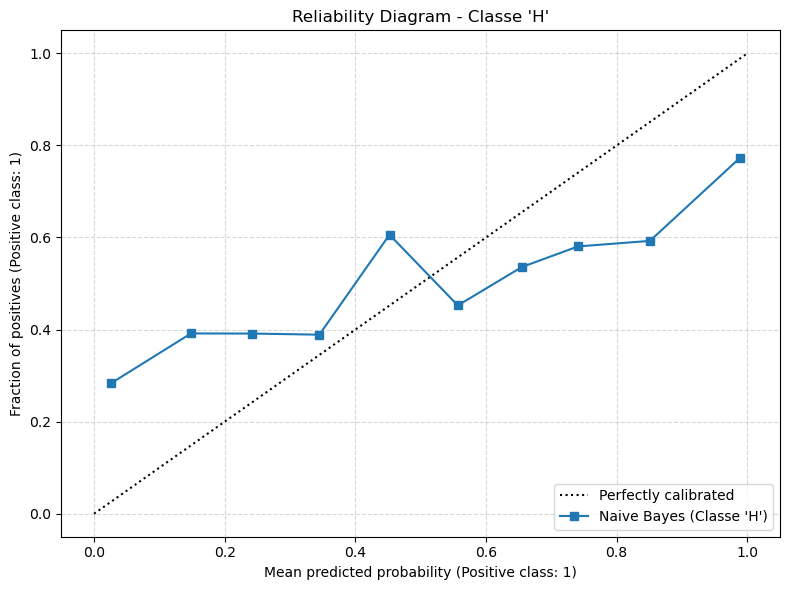

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, log_loss, brier_score_loss
from sklearn.preprocessing import PowerTransformer
from sklearn.calibration import CalibrationDisplay

# --- FUNÇÃO AUXILIAR PARA CALCULAR ECE ---
def compute_ece(y_true, y_proba, n_bins=10):
    """Calcula o Expected Calibration Error."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (y_proba > bin_boundaries[i]) & (y_proba <= bin_boundaries[i + 1])
        prop_in_bin = in_bin.mean()
        if prop_in_bin > 0:
            avg_confidence = y_proba[in_bin].mean()
            avg_accuracy = y_true[in_bin].mean()
            ece += prop_in_bin * np.abs(avg_accuracy - avg_confidence)
    return ece


print("="*60)
print("AVALIAÇÃO DE CALIBRAÇÃO (Classe 'H')")
print("="*60)

# Para métricas como Brier Score e Reliability Diagrams (que são binárias por natureza),
# vamos isolar a classe 'H' (Home) vs o resto.
class_to_evaluate = 'H'
class_idx = np.where(nb_gauss.classes_ == class_to_evaluate)[0][0]

# Converter y_test para formato binário (1 se for 'H', 0 caso contrário)
y_test_binary = (y_test == class_to_evaluate).astype(int)

# Extrair apenas as probabilidades previstas para a classe 'H'
prob_class_h = y_prob[:, class_idx]

# 4. Calcular Métricas de Calibração
brier = brier_score_loss(y_test_binary, prob_class_h)
loss = log_loss(y_test, y_prob) # Log Loss avalia todas as classes de uma vez
ece = compute_ece(y_test_binary, prob_class_h)

print(f"Log Loss (Multiclasse): {loss:.4f} (Mais baixo é melhor)")
print(f"Brier Score (Classe '{class_to_evaluate}'): {brier:.4f} (Mais baixo é melhor, ~0 é perfeito)")
print(f"ECE (Classe '{class_to_evaluate}'): {ece:.4f} (Mais baixo é melhor, ~0 é calibração perfeita)\n")

# 5. Desenhar o Reliability Diagram (Curva de Calibração)
fig, ax = plt.subplots(figsize=(8, 6))

CalibrationDisplay.from_predictions(
    y_test_binary, 
    prob_class_h, 
    n_bins=10, 
    name=f"Naive Bayes (Classe '{class_to_evaluate}')",
    ax=ax
)

ax.set_title(f"Reliability Diagram - Classe '{class_to_evaluate}'")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 4. Otimização de Hiperparâmetros (Bayesian Optimization)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris  # Ou use seus próprios dados
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, log_loss, 
                            brier_score_loss, confusion_matrix, roc_auc_score)
from sklearn.calibration import CalibrationDisplay
from scipy.stats import uniform, randint
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import warnings
warnings.filterwarnings('ignore')

In [70]:
print("\n[2] DEFININDO O ESPAÇO DE HIPERPARÂMETROS...")
print("-"*80)
 
# Espaço de hiperparâmetros para Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l2'],  # Ou 'l1' se solver='liblinear'
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'max_iter': [100, 200, 500, 1000],
    'class_weight': [None, 'balanced'],
}
 
# Distribuições para Random Search
param_dist = {
    'C': uniform(0.001, 1000),
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'max_iter': randint(100, 2000),
    'class_weight': [None, 'balanced'],
}
 
# Espaço para Bayesian Optimization (mais eficiente)
param_bayes = {
    'C': (1e-3, 1e+2, 'log-uniform'),
    # Use solvers que suportam multiclasse nativamente
    'solver': ['lbfgs', 'saga', 'newton-cg'], 
    'max_iter': (100, 1000),
    'class_weight': [None, 'balanced']
}
 
print(f"Espaço de parâmetros definido para Grid/Random/Bayesian Search")
print(f"Total de combinações no Grid: {len(param_grid['C']) * len(param_grid['solver']) * len(param_grid['max_iter']) * len(param_grid['class_weight'])}")


[2] DEFININDO O ESPAÇO DE HIPERPARÂMETROS...
--------------------------------------------------------------------------------
Espaço de parâmetros definido para Grid/Random/Bayesian Search
Total de combinações no Grid: 168


In [66]:
print("\n[3] EXECUTANDO GRID SEARCH...")
print("-"*80)
 
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=0
)
 
grid_search.fit(X_train_scaled, y_train)
 
print(f"✓ Grid Search concluído!")
print(f"  Melhor parâmetro encontrado:")
print(f"    C: {grid_search.best_params_['C']}")
print(f"    Solver: {grid_search.best_params_['solver']}")
print(f"    Max iterations: {grid_search.best_params_['max_iter']}")
print(f"    Class weight: {grid_search.best_params_['class_weight']}")
print(f"  Score de validação cruzada: {grid_search.best_score_:.4f}")


[3] EXECUTANDO GRID SEARCH...
--------------------------------------------------------------------------------
✓ Grid Search concluído!
  Melhor parâmetro encontrado:
    C: 0.1
    Solver: lbfgs
    Max iterations: 100
    Class weight: None
  Score de validação cruzada: 0.5566


In [68]:
print("\n[4] EXECUTANDO RANDOM SEARCH...")
print("-"*80)
 
random_search = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=param_dist,
    n_iter=50,  # Número de combinações a testar
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    random_state=42,
    verbose=0
)
 
random_search.fit(X_train_scaled, y_train)
 
print(f"✓ Random Search concluído!")
print(f"  Melhor parâmetro encontrado:")
print(f"    C: {random_search.best_params_['C']:.4f}")
print(f"    Solver: {random_search.best_params_['solver']}")
print(f"    Max iterations: {random_search.best_params_['max_iter']}")
print(f"    Class weight: {random_search.best_params_['class_weight']}")
print(f"  Score de validação cruzada: {random_search.best_score_:.4f}")


[4] EXECUTANDO RANDOM SEARCH...
--------------------------------------------------------------------------------
✓ Random Search concluído!
  Melhor parâmetro encontrado:
    C: 374.5411
    Solver: saga
    Max iterations: 1394
    Class weight: None
  Score de validação cruzada: 0.5563


In [71]:
print("\n[5] EXECUTANDO BAYESIAN OPTIMIZATION...")
print("-"*80)
 
bayes_search = BayesSearchCV(
    estimator=LogisticRegression(random_state=42),
    search_spaces=param_bayes,
    n_iter=50,  
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    random_state=42,
    verbose=0
)
 
bayes_search.fit(X_train_scaled, y_train)
 
print(f"✓ Bayesian Optimization concluído!")
print(f"  Melhor parâmetro encontrado:")
print(f"    C: {bayes_search.best_params_['C']:.4f}")
print(f"    Solver: {bayes_search.best_params_['solver']}")
print(f"    Max iterations: {bayes_search.best_params_['max_iter']}")
print(f"    Class weight: {bayes_search.best_params_['class_weight']}")
print(f"  Score de validação cruzada: {bayes_search.best_score_:.4f}")


[5] EXECUTANDO BAYESIAN OPTIMIZATION...
--------------------------------------------------------------------------------
✓ Bayesian Optimization concluído!
  Melhor parâmetro encontrado:
    C: 0.0292
    Solver: newton-cg
    Max iterations: 986
    Class weight: None
  Score de validação cruzada: 0.5575


In [72]:
print("\n[6] COMPARAÇÃO DOS MÉTODOS DE OTIMIZAÇÃO...")
print("-"*80)
 
comparison_results = []
 
for name, search_obj in [('Grid Search', grid_search), 
                         ('Random Search', random_search), 
                         ('Bayesian Optimization', bayes_search)]:
    
    # Treinar o melhor modelo no conjunto de treino completo
    best_model = search_obj.best_estimator_
    best_model.fit(X_train_scaled, y_train)
    
    # Predições no conjunto de teste
    y_pred = best_model.predict(X_test_scaled)
    y_pred_proba = best_model.predict_proba(X_test_scaled)
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    loss = log_loss(y_test, y_pred_proba)
    
    # Para dados multiclasse, calcular AUC usando one-vs-rest
    try:
        auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    except:
        auc = np.nan
    
    comparison_results.append({
        'Método': name,
        'Accuracy': accuracy,
        'Log Loss': loss,
        'AUC (OvR)': auc,
        'CV Score': search_obj.best_score_,
        'Num. Iterações': len(search_obj.cv_results_['mean_test_score'])
    })
 
comparison_df = pd.DataFrame(comparison_results)
print("\nRESULTADOS NO CONJUNTO DE TESTE:")
print(comparison_df.to_string(index=False))
 
# Melhor método
best_method_idx = comparison_df['Accuracy'].idxmax()
best_method_name = comparison_df.loc[best_method_idx, 'Método']
print(f"\n★ Melhor Método: {best_method_name}")
 


[6] COMPARAÇÃO DOS MÉTODOS DE OTIMIZAÇÃO...
--------------------------------------------------------------------------------

RESULTADOS NO CONJUNTO DE TESTE:
               Método  Accuracy  Log Loss  AUC (OvR)  CV Score  Num. Iterações
          Grid Search  0.529096  0.953824   0.687060  0.556580             168
        Random Search  0.535363  0.954724   0.686701  0.556282              50
Bayesian Optimization  0.529096  0.952728   0.686780  0.557478              50

★ Melhor Método: Random Search


In [74]:
print("\n[7] AVALIAÇÃO DETALHADA DO MELHOR MODELO...")
print("-"*80)
 
if best_method_name == 'Grid Search':
    best_search = grid_search
elif best_method_name == 'Random Search':
    best_search = random_search
else:
    best_search = bayes_search
 
best_model = best_search.best_estimator_
best_model.fit(X_train_scaled, y_train)
 
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)
 
print(f"\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=best_model.classes_))
 
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
print(f"\nMatriz de Confusão:")
print(cm)


[7] AVALIAÇÃO DETALHADA DO MELHOR MODELO...
--------------------------------------------------------------------------------

Relatório de Classificação:
              precision    recall  f1-score   support

           A       0.58      0.45      0.51       351
           D       0.26      0.03      0.06       274
           H       0.53      0.87      0.66       492

    accuracy                           0.54      1117
   macro avg       0.46      0.45      0.41      1117
weighted avg       0.48      0.54      0.47      1117


Matriz de Confusão:
[[159  15 177]
 [ 65   9 200]
 [ 52  10 430]]


In [79]:
print("\n[8] CONFORMAL PREDICTION - CALIBRAÇÃO E PREDICTION SETS...")
print("-"*80)
 
# Obter probabilidades no conjunto de calibração
cal_probs = best_model.predict_proba(X_cal_scaled)
 
# Mapeamento de classes
label_to_index = {label: i for i, label in enumerate(best_model.classes_)}

# 2. Converter y_cal (rótulos reais) para seus índices numéricos correspondentes
y_cal_indices = np.array([label_to_index[label] for label in y_cal])

# 3. Agora a indexação funcionará corretamente com tipos inteiros[cite: 3]
true_class_probs = cal_probs[np.arange(len(y_cal_indices)), y_cal_indices]
 
# Scores de não-conformidade
scores = 1.0 - true_class_probs
 
# Nível de confiança (90%)
alpha = 0.10
n_cal = len(y_cal_idx)
 
# Quantil corrigido
q_level = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
q_level = min(q_level, 1.0)
threshold = np.quantile(scores, q_level)
 
print(f"Nível de Confiança Alvo: {(1-alpha)*100:.0f}%")
print(f"Limiar de Não-Conformidade: {threshold:.4f}")
 
# Prediction Sets no conjunto de teste
test_probs = best_model.predict_proba(X_test_scaled)
prediction_sets = (1.0 - test_probs) <= threshold
 
# Avaliação de cobertura
y_test_indices = np.array([label_to_index[label] for label in y_test])
is_covered = prediction_sets[np.arange(len(y_test_indices)), y_test_indices]
empirical_coverage = np.mean(is_covered)
set_sizes = prediction_sets.sum(axis=1)
mean_set_size = np.mean(set_sizes)
 
print(f"Cobertura Real Obtida: {empirical_coverage*100:.2f}%")
print(f"Tamanho Médio do Conjunto de Predição: {mean_set_size:.2f} classes")
 
print(f"\nExemplos de Prediction Sets:")
for i in range(min(5, len(y_test))):
    predicted_classes = best_model.classes_[prediction_sets[i]]
    true_class = best_model.classes_[y_test_indices[i]]
    print(f"  Exemplo {i+1}: Classe Real='{true_class}', CP={list(predicted_classes)}")
 


[8] CONFORMAL PREDICTION - CALIBRAÇÃO E PREDICTION SETS...
--------------------------------------------------------------------------------
Nível de Confiança Alvo: 90%
Limiar de Não-Conformidade: 0.7675
Cobertura Real Obtida: 89.53%
Tamanho Médio do Conjunto de Predição: 2.21 classes

Exemplos de Prediction Sets:
  Exemplo 1: Classe Real='H', CP=['A', 'D', 'H']
  Exemplo 2: Classe Real='H', CP=['H']
  Exemplo 3: Classe Real='A', CP=['A', 'D', 'H']
  Exemplo 4: Classe Real='H', CP=['A', 'D', 'H']
  Exemplo 5: Classe Real='A', CP=['A', 'D', 'H']


In [81]:
print("\n[9] AVALIAÇÃO DE CALIBRAÇÃO...")
print("-"*80)
 
def compute_ece(y_true, y_proba, n_bins=10):
    """Calcula Expected Calibration Error."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (y_proba > bin_boundaries[i]) & (y_proba <= bin_boundaries[i + 1])
        prop_in_bin = in_bin.mean()
        if prop_in_bin > 0:
            avg_confidence = y_proba[in_bin].mean()
            avg_accuracy = y_true[in_bin].mean()
            ece += prop_in_bin * np.abs(avg_accuracy - avg_confidence)
    return ece
 
# Focar na primeira classe para análise binária
class_to_evaluate = 0  # Índice da classe
y_test_binary = (y_test == class_to_evaluate).astype(int)
prob_class_0 = y_pred_proba[:, class_to_evaluate]
 
brier = brier_score_loss(y_test_binary, prob_class_0)
loss = log_loss(y_test, y_pred_proba)
ece = compute_ece(y_test_binary, prob_class_0)
 
print(f"\nMÉTRICAS DE CALIBRAÇÃO (Classe '{best_model.classes_[class_to_evaluate]}'):")
print(f"  Log Loss (Multiclasse): {loss:.4f}")
print(f"  Brier Score: {brier:.4f}")
print(f"  ECE (Expected Calibration Error): {ece:.4f}")


[9] AVALIAÇÃO DE CALIBRAÇÃO...
--------------------------------------------------------------------------------

MÉTRICAS DE CALIBRAÇÃO (Classe 'A'):
  Log Loss (Multiclasse): 0.9547
  Brier Score: 0.1326
  ECE (Expected Calibration Error): 0.3055



[10] GERANDO VISUALIZAÇÕES...
--------------------------------------------------------------------------------


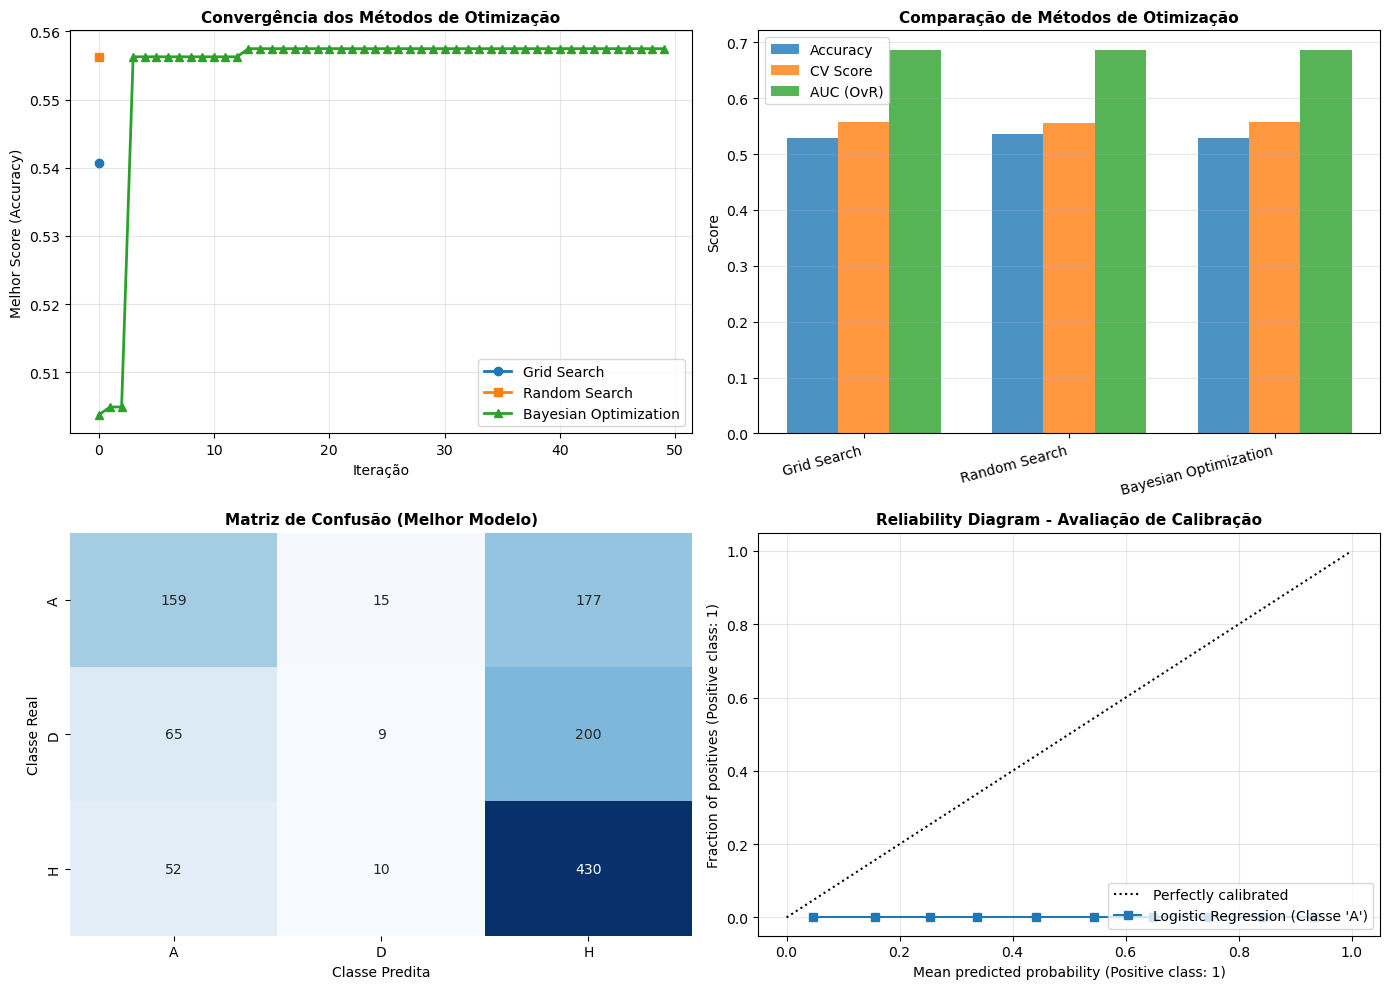

In [86]:
print("\n[10] GERANDO VISUALIZAÇÕES...")
print("-"*80)
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
# 1. Convergência dos métodos de busca
ax = axes[0, 0]
grid_scores = grid_search.cv_results_['mean_test_score']
random_scores = random_search.cv_results_['mean_test_score']
bayes_scores = np.array(bayes_search.cv_results_['mean_test_score'])
 
grid_best = np.maximum.accumulate(grid_scores)
random_best = np.maximum.accumulate(random_scores)
bayes_best = np.maximum.accumulate(bayes_scores)
 
ax.plot(grid_best, 'o-', label='Grid Search', linewidth=2)
ax.plot(random_best, 's-', label='Random Search', linewidth=2)
ax.plot(bayes_best, '^-', label='Bayesian Optimization', linewidth=2)
ax.set_xlabel('Iteração', fontsize=10)
ax.set_ylabel('Melhor Score (Accuracy)', fontsize=10)
ax.set_title('Convergência dos Métodos de Otimização', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
 
# 2. Comparação de métricas
ax = axes[0, 1]
x = np.arange(len(comparison_df))
width = 0.25
ax.bar(x - width, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x, comparison_df['CV Score'], width, label='CV Score', alpha=0.8)
ax.bar(x + width, comparison_df['AUC (OvR)'], width, label='AUC (OvR)', alpha=0.8)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('Comparação de Métodos de Otimização', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Método'], rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
 
# 3. Matriz de confusão
ax = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
ax.set_ylabel('Classe Real', fontsize=10)
ax.set_xlabel('Classe Predita', fontsize=10)
ax.set_title('Matriz de Confusão (Melhor Modelo)', fontsize=11, fontweight='bold')
 
# 4. Reliability Diagram (Calibração)
ax = axes[1, 1]
CalibrationDisplay.from_predictions(
    y_test_binary, 
    prob_class_0, 
    n_bins=10, 
    name=f"Logistic Regression (Classe '{best_model.classes_[class_to_evaluate]}')",
    ax=ax
)
ax.set_title('Reliability Diagram - Avaliação de Calibração', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

In [1]:
print("\n" + "="*80)
print("RESUMO FINAL")
print("="*80)
 
print(f"""
✓ OTIMIZAÇÃO CONCLUÍDA COM SUCESSO
 
1. MÉTODOS DE BUSCA:
   • Grid Search: {comparison_df.iloc[0]['Accuracy']:.4f} (Accuracy)
   • Random Search: {comparison_df.iloc[1]['Accuracy']:.4f} (Accuracy)
   • Bayesian Optimization: {comparison_df.iloc[2]['Accuracy']:.4f} (Accuracy)
 
2. MELHOR MODELO: {best_method_name}
   • Accuracy no Teste: {comparison_df.loc[best_method_idx, 'Accuracy']:.4f}
   • Log Loss: {comparison_df.loc[best_method_idx, 'Log Loss']:.4f}
   • Hiperparâmetros ótimos:
     - C: {best_search.best_params_['C']}
     - Solver: {best_search.best_params_['solver']}
     - Max Iterations: {best_search.best_params_['max_iter']}
     - Class Weight: {best_search.best_params_['class_weight']}
 
3. CONFORMAL PREDICTION:
   • Cobertura Real: {empirical_coverage*100:.2f}% (Alvo: {(1-alpha)*100:.0f}%)
   • Tamanho Médio dos Prediction Sets: {mean_set_size:.2f}
 
4. CALIBRAÇÃO:
   • Brier Score: {brier:.4f}
   • ECE: {ece:.4f}
 
5. DADOS:
   • Treino: {X_train.shape[0]} amostras
   • Calibração: {X_cal.shape[0]} amostras
   • Teste: {X_test.shape[0]} amostras
""")
 
print("="*80)
print("FIM DA OTIMIZAÇÃO")
print("="*80)


RESUMO FINAL


NameError: name 'comparison_df' is not defined

# Parte 3: Teoria de Utilidade e Tomada de Decisão

### 1. Utilidade: Modelo vs Odds

Identificação de discrepâncias significativas entre o modelo e as odds de mercado.

In [ ]:
test_comparison = df.iloc[X_test.index].copy()
test_comparison['prob_H_model'] = nb_model.predict_proba(X_test)[:, list(le_dict['result'].classes_).index('H')]
test_comparison['prob_H_market'] = 1 / test_comparison['h_odds']
test_comparison['disagreement'] = np.abs(test_comparison['prob_H_model'] - test_comparison['prob_H_market'])

print("Casos de maior desacordo (Modelo vs Mercado):")
print(test_comparison.sort_values(by='disagreement', ascending=False).head(5)[['ht', 'at', 'result', 'h_odds', 'prob_H_model', 'prob_H_market']])

Casos de maior desacordo (Modelo vs Mercado):
           ht        at result  h_odds  prob_H_model  prob_H_market
1485    porto  feirense      H    1.13      0.311437       0.884956
1216    porto     naval      H    1.11      0.400785       0.900901
3085  benfica   estoril      H    1.12      0.400785       0.892857
3439  benfica  boavista      H    1.16      0.384872       0.862069
2835  benfica  nacional      H    1.17      0.384872       0.854701


### 2. Reject Option e Deferral

Estratégia de deferir para as odds quando o modelo apresenta alta incerteza.

In [ ]:
def selective_prediction_defer(y_prob, market_probs, threshold=0.45):
    max_probs = np.max(y_prob, axis=1)
    model_preds = np.argmax(y_prob, axis=1)
    market_preds = np.argmax(market_probs, axis=1)
    
    final_preds = np.where(max_probs < threshold, market_preds, model_preds)
    deferred = np.sum(max_probs < threshold)
    return final_preds, deferred

market_probs = test_comparison[['h_odds', 'd_odds', 'a_odds']].apply(lambda x: 1/x, axis=0).values
market_probs = market_probs / market_probs.sum(axis=1, keepdims=True)

final_preds, deferred = selective_prediction_defer(y_prob, market_probs, threshold=0.45)
print(f"Jogos totais: {len(y_test)}")
print(f"Jogos com deferimento para odds: {deferred}")
print(f"Accuracy Final (com Deferral): {accuracy_score(y_test, final_preds):.4f}")

Jogos totais: 1117
Jogos com deferimento para odds: 353
Accuracy Final (com Deferral): 0.4476
